## Plot RUL Predictions

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

from experiment_config import dataset_path, pfnet_paths
from src.helpers.visualization import plot_rul_from_dataframe


## Configuration

In [10]:
DATA_NAME = "DS06"
ARGS_ID = 0


## Import test data


In [11]:
ESTIMATION_DIR = dataset_path(DATA_NAME, field="estimation")
_, PRED_DIR = pfnet_paths(ARGS_ID, DATA_NAME)

In [12]:
hi_df = pd.read_csv(ESTIMATION_DIR / "data_test.csv")
perform_names = [col for col in hi_df.columns if col not in ["unit", "cycle", "hs"]]
test_units = hi_df["unit"].astype(int).unique().tolist()
onsets = {
    unit: hi_df[(hi_df["unit"] == unit) & (hi_df["hs"] == 0)]["cycle"].values[0]
    for unit in test_units
}

test_units


[7, 8, 9, 10]

# Load RUL predictions

In [13]:
# aggregate all individual repetition files in the folder
rep_files = sorted(PRED_DIR.glob("rul_test_r*.csv"))
df_preds = pd.concat((pd.read_csv(f) for f in rep_files), ignore_index=True)
n_reps = int(df_preds["rep"].nunique())
N_REP = n_reps  # alias so downstream plot titles referencing N_REP still resolve
print(f"loaded {len(rep_files)} files ({n_reps} reps)")

loaded 10 files (10 reps)


## Plot RUL Predictions

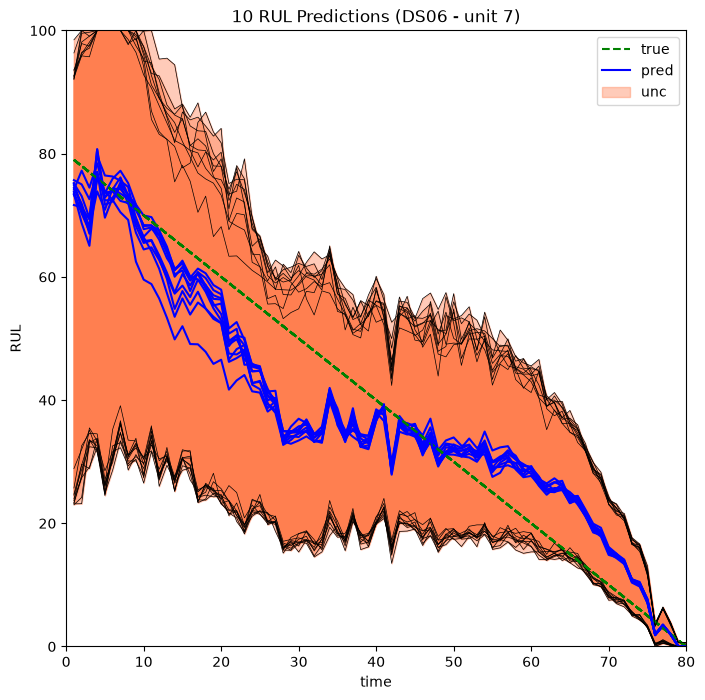

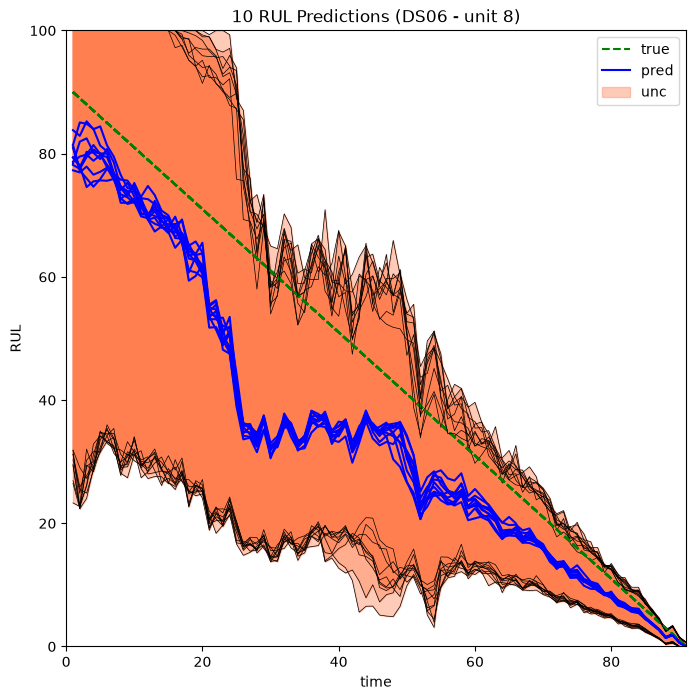

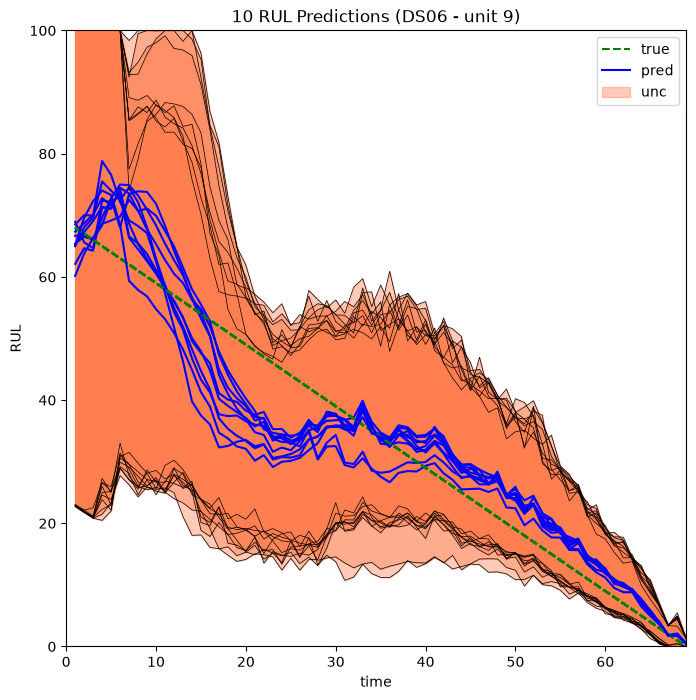

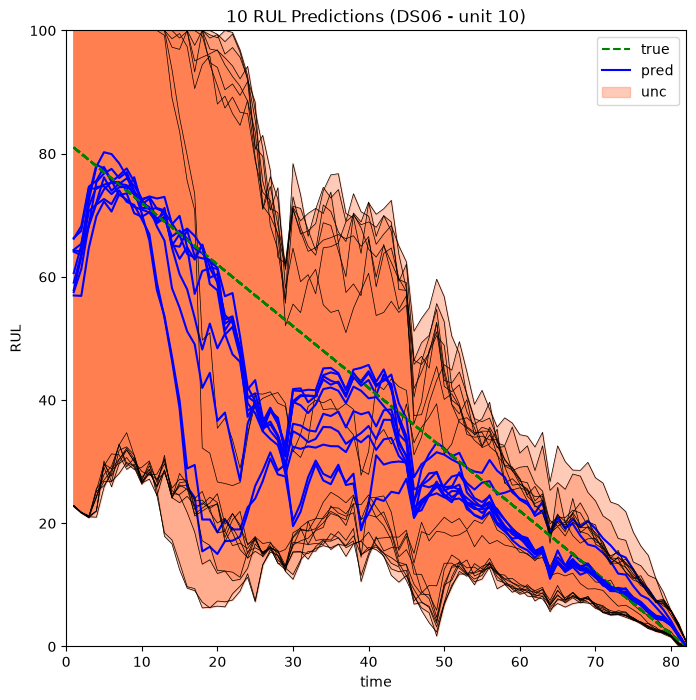

In [14]:
for unit in test_units:
    fig, ax = plt.subplots(figsize=(8, 8))
    for i, rep in enumerate(sorted(df_preds["rep"].unique())):
        df = df_preds[(df_preds["unit"] == unit) & (df_preds["rep"] == rep)]
        eol_time = df["time"].iloc[-1]
        plot_rul_from_dataframe(
            ax=ax,
            df=df,
            t_max=eol_time,
            title=f"{n_reps} RUL Predictions ({DATA_NAME} - unit {unit})",
            show_legend=(i == 0),
        )
        ax.legend(loc="upper right")

## inal RUL Mean Prediction

In [15]:
df_preds = df_preds.groupby(["unit", "time"], as_index=False).mean()

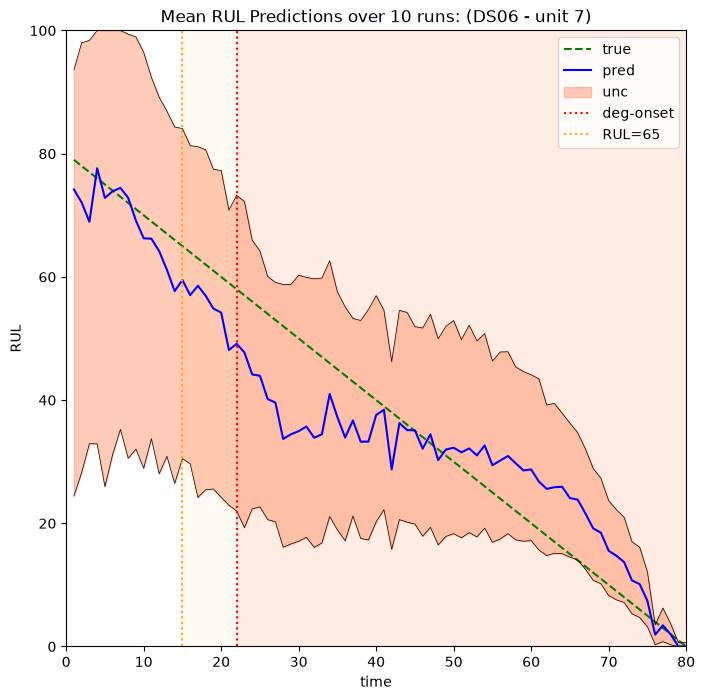

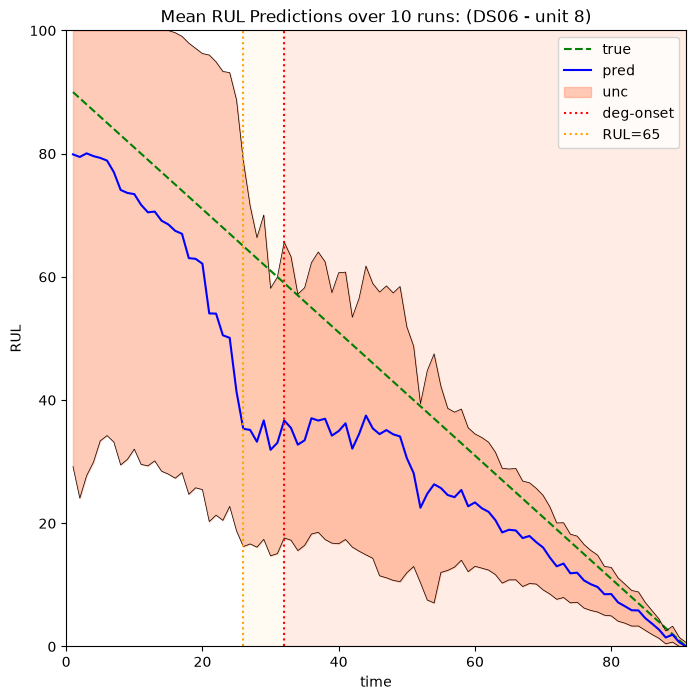

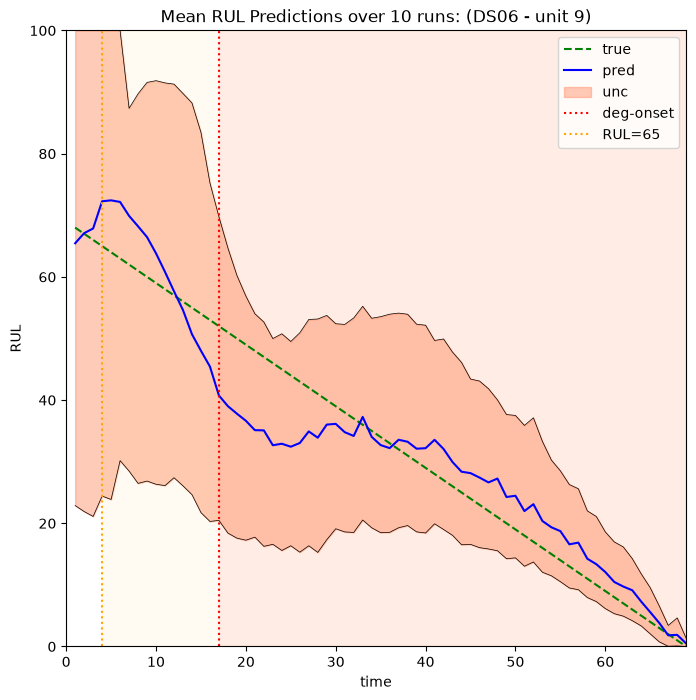

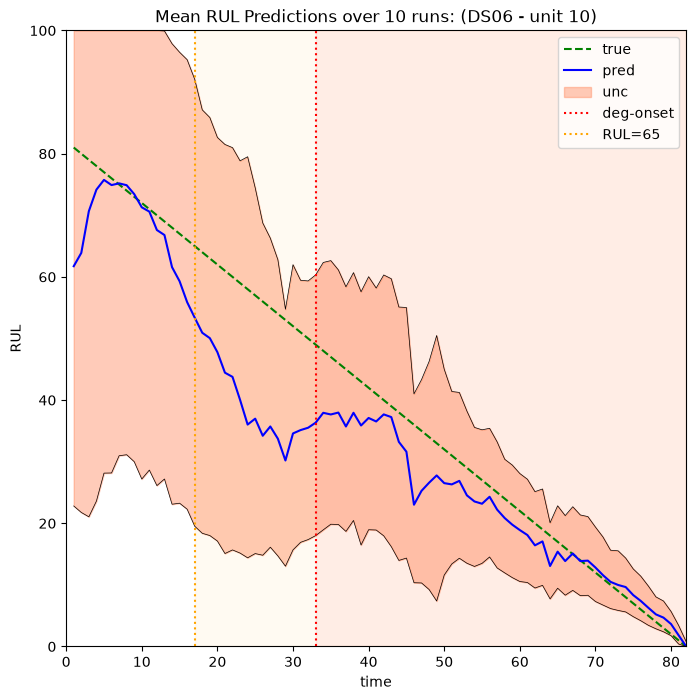

In [16]:
df_preds = df_preds.groupby(["unit", "time"], as_index=False).mean()
for unit in test_units:
    fig, ax = plt.subplots(figsize=(8, 8))
    df = df_preds[df_preds["unit"] == unit]
    eol_time = df["time"].iloc[-1]
    plot_rul_from_dataframe(
        ax=ax,
        df=df,
        t_max=eol_time,
        title=f"Mean RUL Predictions over {N_REP} runs: ({DATA_NAME} - unit {unit})",
        show_legend=True,
    )
    ax.vlines(
        onsets[unit],
        linestyle=":",
        ymin=0,
        ymax=100,
        colors="red",
        linestyles="dashed",
        label="deg-onset",
    )
    ax.vlines(
        eol_time - 65,
        linestyle=":",
        ymin=0,
        ymax=100,
        colors="orange",
        linestyles="dashed",
        label="RUL=65",
    )
    ax.legend(loc="upper right")

    ax.axvspan(eol_time - 65, eol_time, color="orange", alpha=0.05, label="RUL<65")
    ax.axvspan(onsets[unit], eol_time, color="red", alpha=0.05, label="deg")